# Website log analysis — MySQL

Run this notebook with the **numeric** Python environment from the repository root.
It reproduces the country, endpoint, and daily human/robot analyses in
`analyzedb.ipynb` using `philiplessner_logs_test` on MySQL 8.0.40.

Install the MySQL driver and its authentication dependencies in `numeric`:

```bash
conda run -n numeric python -m pip install -r mysql/requirements.txt
```

The existing `ipywidgets`, `matplotlib`, and `python-dotenv` packages are also used.
Start the database with `docker compose -f compose.mysql.yaml up -d --wait`.
Credentials are loaded from `.mysql.env`; passwords are never displayed here.

Select the start/end dates, then rerun the cells below the date pickers. Dates are
inclusive and interpreted in **UTC**. Change the top-N slider and rerun the charts
and exports to update them. The migrated table is a snapshot; ingestion still writes
to SQLite. Only `data.philiplessner.com` has been migrated so far.

The original filters are retained: 404 responses are excluded from human country
counts and daily visits, and included in the other analyses. Robot endpoint
percentages use the robot total, correcting the original notebook's denominator.
HTML exports go to `data.philiplessner.com/mysql-analysis/` and load Chart.js from
its existing CDN URL when opened in a browser.


In [1]:
import json
import os
from datetime import date, datetime, time, timedelta
from pathlib import Path
from typing import Any

import ipywidgets as widgets
import matplotlib.pyplot as plt
import pymysql
from dotenv import dotenv_values
from IPython.display import display


In [2]:
def query_results(query: str, database: str, parameters: tuple | None = None) -> list[Any]:
    # Use bound parameters and close each connection after its read-only query.
    with pymysql.connect(**mysql_config, database=database) as conn:
        with conn.cursor() as cursor:
            cursor.execute("START TRANSACTION READ ONLY")
            cursor.execute(query, parameters or ())
            return list(cursor.fetchall())


def visit_percentages(counts: list[int]) -> list[float]:
    total = sum(counts)
    return [count / total * 100.0 for count in counts] if total else [0.0 for _ in counts]


In [3]:
# Read credentials from the same file used by the MySQL test container.
root_path = Path.cwd()
config_path = root_path / '.mysql.env'
if not config_path.is_file():
    raise FileNotFoundError('Open this notebook from the logs repository containing .mysql.env.')

mysql_env = dotenv_values(config_path, interpolate=False)
for key in ('MYSQL_USER', 'MYSQL_PASSWORD', 'MYSQL_DATABASE'):
    if not mysql_env.get(key):
        raise ValueError(f'Missing {key} in .mysql.env')

mysql_config = {
    'host': os.environ.get('MYSQL_HOST', '127.0.0.1'),
    'port': int(os.environ.get('MYSQL_PORT', '3307')),
    'user': mysql_env['MYSQL_USER'],
    'password': mysql_env['MYSQL_PASSWORD'],
    'charset': 'utf8mb4',
    'connect_timeout': 10,
    'read_timeout': 60,
    'write_timeout': 60,
    'init_command': "SET SESSION time_zone = '+00:00'",
}

# Only philiplessner.com has been copied to MySQL so far.
choices = [mysql_env['MYSQL_DATABASE']]
listbox = widgets.Select(options=choices, description='Database:', rows=1, value=choices[0])
display(listbox)


Select(description='Database:', options=('philiplessner_logs_test',), rows=1, value='philiplessner_logs_test')

In [4]:
database = listbox.value
server_version, database_name = query_results('SELECT VERSION(), DATABASE()', database)[0]
row_count, first_visit, last_visit = query_results(
    'SELECT COUNT(*), MIN(datetime), MAX(datetime) FROM logs', database
)[0]
print(f'MySQL {server_version}: {database_name} ({row_count:,} records)')
print(f'Available dates (UTC): {first_visit} to {last_visit}')

# Keep these HTML exports separate from the SQLite notebook's exports.
data_dir = root_path / 'data.philiplessner.com' / 'mysql-analysis'
data_dir.mkdir(parents=True, exist_ok=True)
print(f'HTML exports: {data_dir}')


MySQL 8.0.40: philiplessner_logs_test (8,949 records)
Available dates (UTC): 2026-07-12 11:11:43 to 2026-09-25 03:22:06
HTML exports: /media/phil/m2ssd/web/logs/data.philiplessner.com/mysql-analysis


In [5]:
# Select inclusive calendar dates in UTC, then rerun the cells below.
date_start = widgets.DatePicker(description='Start Date', value=date.today())
date_end = widgets.DatePicker(description='End Date', value=date.today())
display(date_start)
display(date_end)


DatePicker(value=datetime.date(2026, 9, 25), description='Start Date', step=1)

DatePicker(value=datetime.date(2026, 9, 25), description='End Date', step=1)

In [6]:
if date_start.value is None or date_end.value is None:
    raise ValueError('Select both a start date and an end date.')
if date_start.value > date_end.value:
    raise ValueError('The start date must be on or before the end date.')

# Include the full end date, including any fractional-second timestamps.
# MySQL DATETIME values in this database are stored in UTC.
start_date = datetime.combine(date_start.value, time.min)
end_exclusive = datetime.combine(date_end.value + timedelta(days=1), time.min)
sdate = date_start.value.isoformat()
edate = date_end.value.isoformat()


In [7]:
country_query_humans = """
    SELECT countryCode, COUNT(*) AS count
    FROM logs
    WHERE Agent_Type = 'H'
    AND status_code <> 404
    AND `datetime` >= %s AND `datetime` < %s
    GROUP BY countryCode
    ORDER BY count DESC, countryCode ASC
    """
country_counts_humans = query_results(country_query_humans, database, (start_date, end_exclusive))
countryCodes_humans = [countryCode for countryCode, _ in country_counts_humans]
counts_humans = [count for _, count in country_counts_humans]
percentages_humans = visit_percentages(counts_humans)


In [8]:
country_query_robots = """
    SELECT countryCode, COUNT(*) AS count
    FROM logs
    WHERE Agent_Type = 'R'
    AND `datetime` >= %s AND `datetime` < %s
    GROUP BY countryCode
    ORDER BY count DESC, countryCode ASC
    """

country_counts_robots = query_results(country_query_robots, database, (start_date, end_exclusive))
countryCodes_robots = [countryCode for countryCode, _ in country_counts_robots]
counts_robots = [count for _, count in country_counts_robots]
percentages_robots = visit_percentages(counts_robots)


In [9]:
# Get n for top(n) countries to display
top_n = widgets.IntSlider(
    value=10,
    min=0,
    max=50,
    step=1,
    description='Value:',
    continuous_update=False
)

display(top_n)


IntSlider(value=10, continuous_update=False, description='Value:', max=50)

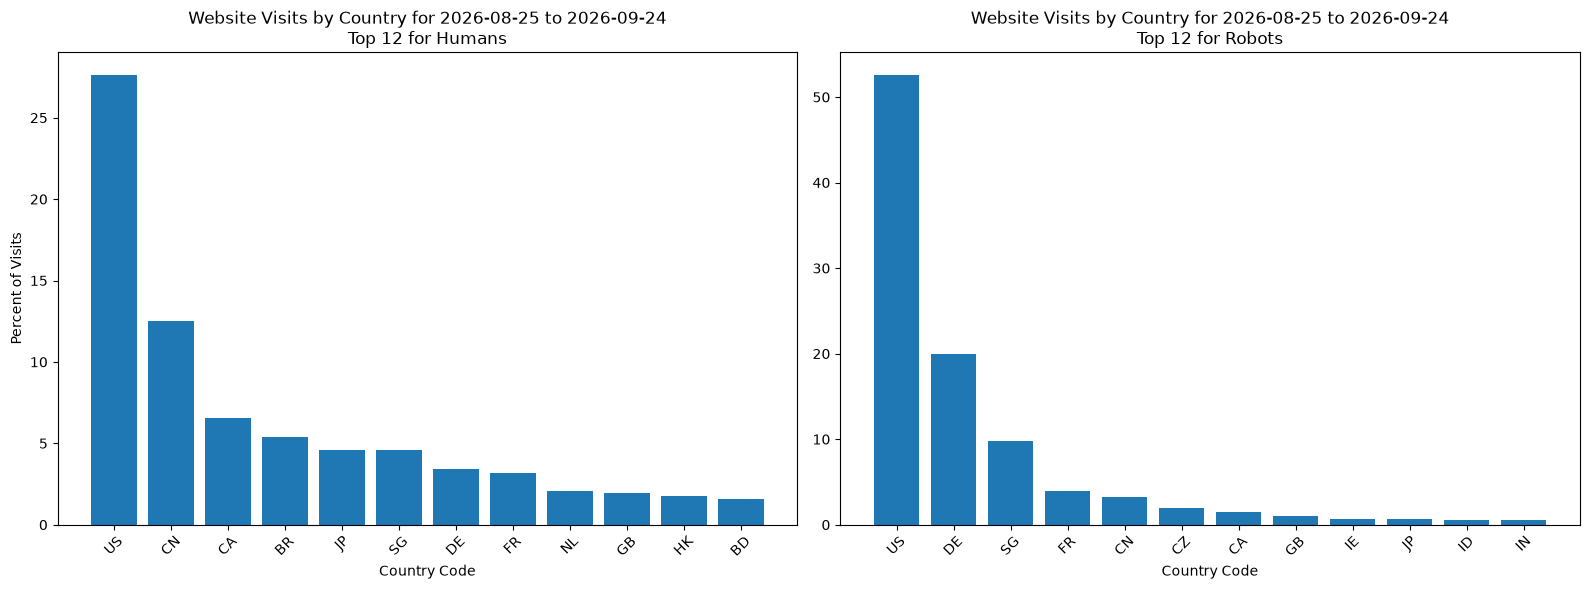

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(countryCodes_humans[:top_n.value], percentages_humans[:top_n.value])
axes[0].set_title(f'Website Visits by Country for {date_start.value} to {date_end.value}\nTop {top_n.value} for Humans')
axes[0].set_xlabel('Country Code')
axes[0].set_ylabel('Percent of Visits')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(countryCodes_robots[:top_n.value], percentages_robots[:top_n.value])
axes[1].set_title(f'Website Visits by Country for {date_start.value} to {date_end.value}\nTop {top_n.value} for Robots')
axes[1].set_xlabel('Country Code')
axes[1].tick_params(axis='x', rotation=45)

fig.tight_layout()


In [11]:
countryvisits_html = f"""
<html>
<div>
  <canvas id="myChart"></canvas>
</div>

<script src="https://cdn.jsdelivr.net/npm/chart.js@4.5.1/dist/chart.umd.min.js"></script>

<script>
  const ctx = document.getElementById('myChart');

  new Chart(ctx, {{
    type: 'bar',
    data: {{
      labels: {json.dumps(countryCodes_humans[:top_n.value])},
      datasets: [{{
        data: {json.dumps(percentages_humans[:top_n.value])},
        borderWidth: 1
      }}]
    }},
    options: {{
    plugins: {{
            title: {{
                display: true,
                text: 'Percent Website Visits by Country for {sdate} to {edate}',
          font: {{
            family: 'Arial',
            size: 18,
          }}
            }},
            legend: {{
                display: false,
                labels: {{
                    color: 'rgb(255, 99, 132)'
                }}
            }}
        }},
      scales: {{
        y: {{
          beginAtZero: true,
          title: {{
          display: true,
          text: 'Percent of (Human) Visits',
          color: '#111',
          font: {{
            family: 'Arial',
            size: 16,
          }}
          }}
        }},
        x: {{
          title: {{
          display: true,
          text: 'Country Code',
          color: '#111',
          font: {{
            family: 'Arial',
            size: 16,
          }}
          }}
        }}
      }}
    }}
  }});
</script>
</html>
"""

with open(Path(data_dir, 'countryCode_percent.html'), 'w', encoding='utf-8') as f:
    f.write(countryvisits_html)


In [12]:
endpoint_query_humans = """
    SELECT endpoint, COUNT(*) AS count
    FROM logs
    WHERE Agent_Type = 'H'
    AND `datetime` >= %s AND `datetime` < %s
    GROUP BY endpoint
    ORDER BY count DESC, endpoint ASC
    """

endpoint_counts_humans = query_results(endpoint_query_humans, database, (start_date, end_exclusive))
endpoints_humans = [endpoint for endpoint, _ in endpoint_counts_humans]
counts_humans = [count for _, count in endpoint_counts_humans]
percentages_humans = visit_percentages(counts_humans)


In [13]:
endpoint_query_robots= """
    SELECT endpoint, COUNT(*) AS count
    FROM logs
    WHERE Agent_Type = 'R'
    AND `datetime` >= %s AND `datetime` < %s
    GROUP BY endpoint
    ORDER BY count DESC, endpoint ASC
    """

endpoint_counts_robots = query_results(endpoint_query_robots, database, (start_date, end_exclusive))
endpoints_robots = [endpoint for endpoint, _ in endpoint_counts_robots]
counts_robots = [count for _, count in endpoint_counts_robots]
percentages_robots = visit_percentages(counts_robots)


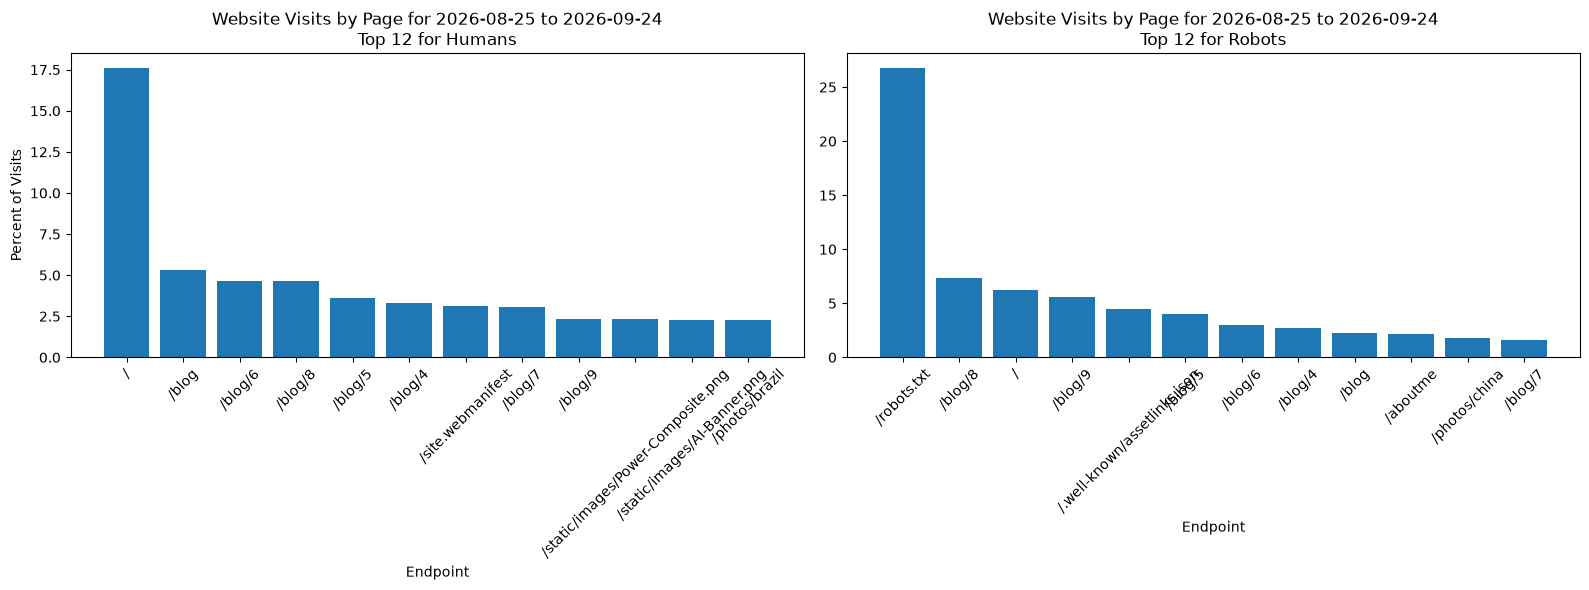

In [14]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(endpoints_humans[:top_n.value], percentages_humans[:top_n.value])
axes[0].set_title(f'Website Visits by Page for {date_start.value} to {date_end.value}\nTop {top_n.value} for Humans')
axes[0].set_xlabel('Endpoint')
axes[0].set_ylabel('Percent of Visits')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(endpoints_robots[:top_n.value], percentages_robots[:top_n.value])
axes[1].set_title(f'Website Visits by Page for {date_start.value} to {date_end.value}\nTop {top_n.value} for Robots')
axes[1].set_xlabel('Endpoint')
axes[1].tick_params(axis='x', rotation=45)

fig.tight_layout()


In [15]:

endpoint_html = f"""
<html>
<div>
  <canvas id="myChart"></canvas>
</div>

<script src="https://cdn.jsdelivr.net/npm/chart.js@4.5.1/dist/chart.umd.min.js"></script>

<script>
  const ctx = document.getElementById('myChart');

  new Chart(ctx, {{
    type: 'bar',
    data: {{
      labels: {json.dumps(endpoints_humans[:top_n.value])},
      datasets: [{{
        label: 'Percent Visits by Endpoint for {sdate} to {edate}',
        data: {json.dumps(percentages_humans[:top_n.value])},
        borderWidth: 1
      }}]
    }},
    options: {{
    plugins: {{
            title: {{
                display: true,
                text: 'Percent Visits by Endpoint for {sdate} to {edate}',
          font: {{
            family: 'Arial',
            size: 18,
          }}
            }},
            legend: {{
                display: false,
                labels: {{
                    color: 'rgb(255, 99, 132)'
                }}
            }}
        }},
      scales: {{
        y: {{
          beginAtZero: true,
          title: {{
          display: true,
          text: 'Percent of (Human) Visits',
          color: '#111',
          font: {{
            family: 'Arial',
            size: 16,
          }}
          }}
        }},
        x: {{
          title: {{
          display: true,
          text: 'Endpoint',
          color: '#111',
          font: {{
            family: 'Arial',
            size: 16,
          }}
          }}
        }}
      }}
    }}
  }});
</script>
</html>
"""

with open(Path(data_dir, 'endpoint_percentages.html'), 'w', encoding='utf-8') as f:
    f.write(endpoint_html)


In [16]:
visits_query = """
SELECT DATE(datetime) AS visit_day,
       COUNT(*) AS total_visits,
       COUNT(CASE WHEN Agent_Type = 'H' THEN 1 END) AS human_visits,
       COUNT(CASE WHEN Agent_Type = 'R' THEN 1 END) AS robot_visits
FROM logs
WHERE `datetime` >= %s AND `datetime` < %s
AND status_code <> 404
GROUP BY DATE(datetime)
ORDER BY visit_day;
"""

visits_counts = query_results(visits_query, database, (start_date, end_exclusive))
dates = [visit_day.isoformat() for visit_day, _, _, _ in visits_counts]
humans = [human for _,_, human, _ in visits_counts]
robots = [robot for _, _, _, robot in visits_counts]


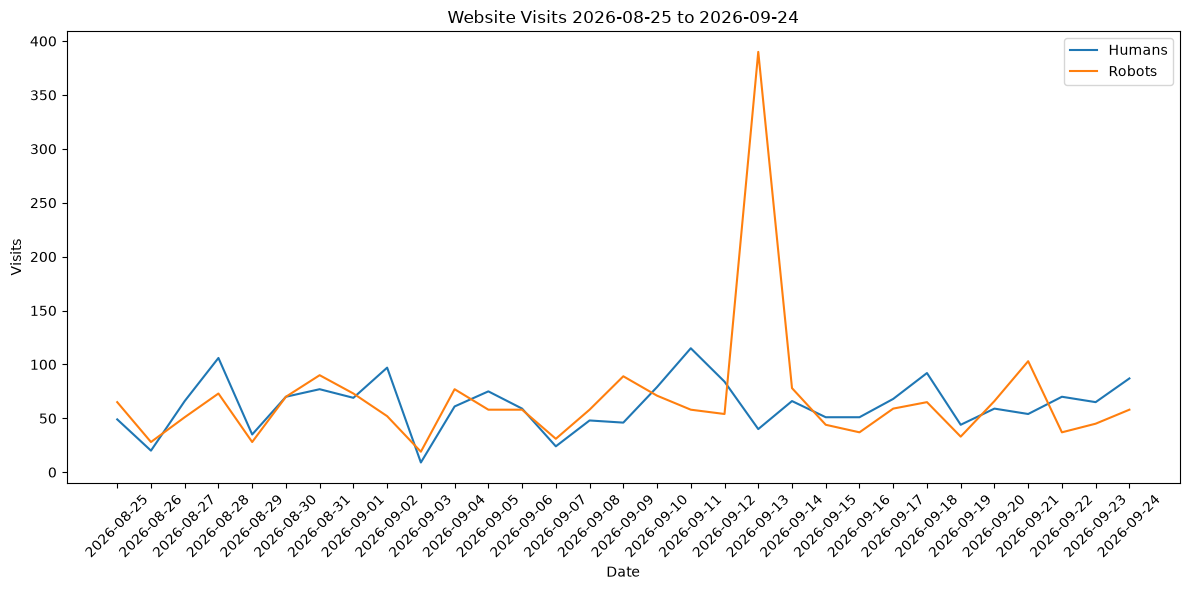

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(dates, humans, label='Humans')
plt.plot(dates, robots, label='Robots')
plt.title(f'Website Visits {sdate} to {edate}')
plt.xlabel('Date')
plt.ylabel('Visits')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()


In [18]:
visitbytype_html = f"""
<html>
<div>
  <canvas id="myChart"></canvas>
</div>

<script src="https://cdn.jsdelivr.net/npm/chart.js@4.5.1/dist/chart.umd.min.js"></script>

<script>
const ctx = document.getElementById('myChart').getContext('2d');

const myChart = new Chart(ctx, {{
    type: 'line', // Sets the chart type to line
    data: {{
        labels: {json.dumps(dates)}, // Shared X-axis labels
        datasets: [
            {{
                label: 'Humans', // Name shown in the legend
                data: {json.dumps(humans)},  // Y-axis values for the first line
                borderColor: 'rgb(255, 99, 132)', // Line color
                backgroundColor: 'rgba(255, 99, 132, 0.2)', // Fill color under the line
                tension: 0.1 // Makes the line slightly curved
            }},
            {{
                label: 'Robots', // Name shown in the legend
                data: {json.dumps(robots)},  // Y-axis values for the second line
                borderColor: 'rgb(54, 162, 235)', // Line color
                backgroundColor: 'rgba(54, 162, 235, 0.2)', // Fill color under the line
                tension: 0.1
            }}
        ]
    }},
    options: {{
        responsive: true, // Chart resizes automatically
        plugins: {{
            title: {{
                display: true,
                text: 'Daily Visits',
          font: {{
            family: 'Arial',
            size: 18,
          }}
            }},
            legend: {{
                position: 'right', // Legend placement
            }}
        }},
      scales: {{
        y: {{
          beginAtZero: true,
          title: {{
          display: true,
          text: 'Visits',
          color: '#111',
          font: {{
            family: 'Arial',
            size: 16,
          }}
          }}
        }},
        x: {{
          title: {{
          display: true,
          text: 'Date',
          color: '#111',
          font: {{
            family: 'Arial',
            size: 16,
          }}
          }}
        }}
      }}
    }}}})
</script>
</html>
"""
with open(Path(data_dir, 'visitbytype.html'), 'w', encoding='utf-8') as f:
    f.write(visitbytype_html)
